<a href="https://colab.research.google.com/github/Zhr-Srj/TripSimAcin-AMR/blob/main/Code/IC_Q4_External_validation1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook we want to train TSA-Net model and validate it 5 times with strain-aside dataset on IC_Q4_selected features (**3092**) and drug features (**881**) and get an average over validation metrics' values.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Required packages

In [ ]:
pip install xgboost

In [ ]:
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import random
from random import sample, shuffle

from sklearn.utils import shuffle as sk_shuffle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import KFold

from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.callbacks import  History

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Data

## Loading dataset with SHAP selected features

In [ ]:
with open(r'/content/drive/MyDrive/Dataset19.txt') as f:
    data = []
    for line in f.readlines():
        row = []
        for elem in line.split(sep=','):
            row.append(int(elem.strip()))
        data.append(row)
print(len(data))
print(len(data[0]))

7207
8886


In [ ]:
#Reading phenotypes file
with open(r'/content/drive/MyDrive/drugLabel19.txt') as fy:
    labels = []
    drugs = [] #stores drug name in each row
    row = 0 # row number of each label (is needed because data is reordered while spliting)
    reader = csv.reader(fy)
    for i in reader:
        labels.append([row, int(i[1])])
        drugs.append(i[0])
        row += 1

print(len(labels))
print(len(drugs))
print(labels[:5])

7207
7207
[[0, 1], [1, 1], [2, 0], [3, 0], [4, 1]]


In [ ]:
labels = np.asarray(labels)

# Loading IC-based features

In [ ]:
ic_selection = []
with open("/content/drive/MyDrive/Master_new_Sep/Revise/IC4thq_selected_features.txt") as f:
  for i in f.readlines():
    ic_selection.append(int(i.strip()))

print(len(ic_selection))

3092


In [ ]:
for i in range(8005, 8886):
  ic_selection.append(i)

print(len(ic_selection))

3973


In [ ]:
data_np = np.asarray(data)

all_selected_indices = sorted(ic_selection)

data_ic = data_np[:, all_selected_indices]

print(len(data_ic))
print(len(data_ic[0]))

7207
3973


In [ ]:
del data_np
data = data_ic
del data_ic

In [ ]:
data = data.tolist()

### Removing duplicates

In [ ]:
duplicate = any(data.count(element) > 1 for element in data)
duplicate

True

In [ ]:
l = [data.count(element) > 1 for element in data]
l[:10]

[True, False, False, True, False, False, True, True, False, True]

In [ ]:
len([i for i in l if i==True])

1015

In [ ]:
reps = {}
for element in data:
  if np.asarray(element).tobytes() not in reps.keys():
    num = data.count(element)
    if num > 1:
      reps[np.asarray(element).tobytes()] = num

In [ ]:
len(reps.keys())

413

In [ ]:
reps.values()

dict_values([2, 2, 4, 2, 4, 2, 2, 4, 3, 4, 2, 3, 3, 3, 3, 2, 2, 2, 5, 2, 2, 2, 5, 4, 3, 2, 2, 2, 2, 2, 3, 2, 3, 5, 2, 2, 2, 2, 3, 4, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 5, 3, 2, 3, 3, 3, 2, 2, 2, 2, 3, 2, 2, 2, 3, 4, 3, 4, 4, 2, 3, 2, 2, 2, 3, 5, 2, 2, 2, 2, 4, 2, 3, 3, 4, 2, 3, 2, 3, 4, 2, 3, 2, 2, 3, 2, 2, 3, 2, 4, 3, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 5, 3, 3, 3, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 5, 3, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 5, 2, 2, 2, 3, 4, 2, 2, 3, 2, 3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 4, 3, 2, 2, 2, 2, 5, 3, 2, 2, 2, 2, 2, 4, 3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 3, 2, 2, 2, 2, 5, 3, 2, 4, 5, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 4, 2, 2, 3, 2, 2, 4, 2, 2, 2, 2, 2, 5, 2, 2, 3, 2, 4, 5, 3, 2, 5, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 5, 2, 2, 2, 5, 2, 2, 5, 2, 2, 2, 5, 3, 2, 2, 2, 3, 2, 2, 2, 4, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [ ]:
sum(reps.values())

1015

In [ ]:
print(len(data))
print( sum(reps.values()) )
print(len(reps.keys()))
print(len(data) - sum(reps.values()) + len(reps.keys()))

7207
1015
413
6605


In [ ]:
added = []
data_unique = []
drugs_unique = []

labels_unique = []
for idx, element in enumerate(data):
  if np.asarray(element).tobytes() not in added:
    added.append(np.asarray(element).tobytes())
    data_unique.append(element)
    labels_unique.append(labels[idx])
    drugs_unique.append(drugs[idx])

len(data_unique)

6605

In [ ]:
orig_data = data_unique
orig_labels = labels_unique

In [ ]:
del data_unique
len(orig_data)

6605

In [ ]:
del labels_unique
len(orig_labels)

6605

In [ ]:
duplicate = any(orig_data.count(element) > 1 for element in orig_data)
duplicate

False

## A survey on data

In [ ]:
unq_drugs = set(drugs)
len(unq_drugs)

12

In [ ]:
per_drug_dic = {}
for i in orig_labels:
  drug = drugs[i[0]]
  label = i[1]
  if drug not in per_drug_dic.keys():
    per_drug_dic[drug] = [0, 0]  # num of resistant, num of susceptible
  if label == 0:
    per_drug_dic[drug][1] += 1
  else:
    per_drug_dic[drug][0] += 1

per_drug_dic

{'gentamicin': [572, 94],
 'levofloxacin': [459, 146],
 'ceftazidime': [526, 105],
 'imipenem': [196, 508],
 'tetracycline': [511, 182],
 'amikacin': [299, 395],
 'cefotaxime': [568, 31],
 'ciprofloxacin': [651, 97],
 'ceftriaxone': [633, 34],
 'meropenem': [165, 173],
 'doripenem': [51, 148],
 'moxifloxacin': [57, 29]}

## Loading strain-aside dataset

In [ ]:
f1 = open(r'/content/drive/MyDrive/Strain_aside_Dataset.txt')

external_test_set = []

for line in f1.readlines():
    row = []
    for elem in line.split(sep=','):
        row.append(int(elem.strip()))
    external_test_set.append(row)

print(len(external_test_set))
print(len(external_test_set[0]))

f1.close()

1371
8886


In [ ]:
#Reading phenotypes file
with open(r'/content/drive/MyDrive/Strain_aside_drugLabels.txt') as fy:
    external_test_labels = []
    external_test_drugs = [] #stores drug name in each row
    row = 0 # row number of each label (is needed because data is reordered while spliting)
    reader = csv.reader(fy)
    for i in reader:
        external_test_labels.append([row, int(i[1])])
        external_test_drugs.append(i[0])
        row += 1

print(len(external_test_labels))
print(len(external_test_drugs))
print(external_test_labels[:5])

1371
1371
[[0, 1], [1, 1], [2, 1], [3, 1], [4, 1]]


In [ ]:
external_test_labels = np.asarray(external_test_labels)

In [ ]:
len(set(external_test_drugs))

10

In [ ]:
set(external_test_drugs)

{'amikacin',
 'cefotaxime',
 'ceftazidime',
 'ceftriaxone',
 'ciprofloxacin',
 'gentamicin',
 'imipenem',
 'levofloxacin',
 'meropenem',
 'tetracycline'}

In [ ]:
unq_drugs = set(external_test_drugs)
len(unq_drugs)

10

In [ ]:
per_drug_dic = {}
for i, drug in enumerate(external_test_drugs):
  if drug not in per_drug_dic.keys():
    per_drug_dic[drug] = [0, 0]  # num of resistant, num of susceptible
  if external_test_labels[i][1] == 0:
    per_drug_dic[drug][1] += 1
  else:
    per_drug_dic[drug][0] += 1

per_drug_dic

{'ciprofloxacin': [211, 23],
 'gentamicin': [202, 35],
 'ceftriaxone': [206, 4],
 'amikacin': [181, 26],
 'ceftazidime': [211, 14],
 'meropenem': [75, 6],
 'levofloxacin': [66, 6],
 'imipenem': [75, 6],
 'tetracycline': [14, 0],
 'cefotaxime': [10, 0]}

In [ ]:
data_np = np.asarray(external_test_set)

all_selected_indices = sorted(ic_selection)

data_ic = data_np[:, all_selected_indices]

print(len(data_ic))
print(len(data_ic[0]))

1371
3973


In [ ]:
del data_np
external_test_set = data_ic
del data_ic

In [ ]:
external_test_set = external_test_set.tolist()

# Required functions

In [ ]:
def make_balanced_triplets(samples, labels, drugs, num):
  """For each drug in drugs samples...
  makes:
  - n triplets which are both Susceptible to drug (S, S)
  - n triplets which are (R, R)
  - n triplets which are (S, R)
  - n triplets which are (R, S)
  """
  bac_shape = 3092

  idx = {} # A dic containig indices of susceptible and resistant strain
            # for each drug

  triplet = [] # Made from samples which are not part of external_test_sets
  triLabels = [] # Labels corresponding to triplets

  unq_drugs = list(set(drugs))

  for drug_name in unq_drugs:
    drug_indx_S = []
    drug_indx_R = []
    for i in range(len(labels)):
      j, l = labels[i][0], labels[i][1]
      if drugs[j] == drug_name:
        if l == 0:
          drug_indx_S.append(i)
        else:
          drug_indx_R.append(i)
    idx[(drug_name, 'S')] = drug_indx_S
    idx[(drug_name, 'R')] = drug_indx_R

  for drug in unq_drugs:

    s_len = len(idx[(drug, 'S')])
    r_len = len(idx[(drug, 'R')])
    n = min(num, int(s_len*(s_len-1)/2), int(r_len*(r_len-1)/2))

    ss = [(i, j) for i in idx[(drug, 'S')] for j in idx[(drug, 'S')] if j>i]
    ss_sampled = sample(ss, n)

    rr = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'R')] if j>i]
    rr_sampled = sample(rr, n)

    rs = [(i, j) for i in idx[(drug, 'R')] for j in idx[(drug, 'S')]]
    neg_samples = sample(rs, 2*n)
    rs_sampled = neg_samples[:n]
    sr_sampled = [(t[1], t[0]) for t in neg_samples[n:]]

    for k in range(n):
      # Making (S, S, d) triplets
      triplet.append( samples[ss_sampled[k][0]][:bac_shape] + samples[ss_sampled[k][1]][:bac_shape] +
                        samples[ss_sampled[k][0]][bac_shape:] )
      triLabels.append([1, 0]) # 1: both phenos the same. First: 0, sencond? --> 0

      # Making (R, R, d) triplets
      triplet.append( samples[rr_sampled[k][0]][:bac_shape] + samples[rr_sampled[k][1]][:bac_shape] +
                        samples[rr_sampled[k][0]][bac_shape:] )
      triLabels.append([1, 1]) # 1: both phenos the same. First: 1, sencond? --> 1

      # Making (R, S, d) triplets
      triplet.append( samples[rs_sampled[k][0]][:bac_shape] + samples[rs_sampled[k][1]][:bac_shape] +
                         samples[rs_sampled[k][0]][bac_shape:])
      triLabels.append([0, 1]) # 0: phenos different. First: 1, sencond? --> 0

      # Making (S, R, d) triplets
      triplet.append( samples[sr_sampled[k][0]][:bac_shape] + samples[sr_sampled[k][1]][:bac_shape] +
                         samples[sr_sampled[k][0]][bac_shape:])
      triLabels.append([0, 0]) # 0: phenos different. First: 0, sencond? --> 1

  return np.array(triplet), np.array(triLabels)

In [ ]:
def evaluation(true_labels, pred_labels):

  Dis_pred = []
  for i in pred_labels:
    if i < 0.5:
      Dis_pred.append(0)
    else:
      Dis_pred.append(1)

  acc = accuracy_score(true_labels, Dis_pred)
  auc = roc_auc_score(true_labels, Dis_pred)
  print('Accuracy: ', acc)
  print('ROC-AUC: ', auc)

  TN, FP, FN, TP = confusion_matrix(true_labels, Dis_pred, labels=[0, 1]).ravel()
  sen = TP/(TP+FN)
  spc = TN/(TN+FP)
  print("Sensitivity: ", sen)
  print('Specificity: ', spc)

  conf_matrix = confusion_matrix(true_labels, Dis_pred, labels=[0, 1])
  plt.figure(figsize=(4, 4))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Predicted Negative', 'Predicted Positive'],
              yticklabels=['True Negative', 'True Positive'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

  return acc, auc, sen, spc

# TripSimAcin-AMR framework

## TSA-Net architecture

In [ ]:
input_shape1 = (3092,) # Strain feature vector length
input_shape2 = (3092,)
input_shape3 = (881,) # Antibiotic feature vector length

In [ ]:
def create_siamese_model(input_shape1, input_shape2, input_shape3):

    right_input = Input(shape=input_shape2)
    left_input = Input(shape=input_shape1)
    third_input = Input(shape=input_shape3)

    shared_layer1 = Dense(1024, activation='leaky_relu')
    shared_layer2 = Dense(512, activation='leaky_relu')
    shared_layer3 = Dense(256, activation='leaky_relu')
    shared_bn = BatchNormalization() # shared batch normalization layer
    drug_bn = BatchNormalization() # drug batch normalization layer

    encoded_l = shared_layer1(left_input)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer2(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_layer3(encoded_l)
    encoded_l = Dropout(0.2)(encoded_l)
    encoded_l = shared_bn(encoded_l)

    encoded_r = shared_layer1(right_input)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer2(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_layer3(encoded_r)
    encoded_r = Dropout(0.2)(encoded_r)
    encoded_r = shared_bn(encoded_r)

    encoded_c = Dense(256, activation='leaky_relu')(third_input)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = Dense(128, activation='leaky_relu')(third_input)
    encoded_c = Dropout(0.2)(encoded_c)
    encoded_c = drug_bn(encoded_c)

    concatenated = Concatenate()([encoded_l, encoded_r, encoded_c])

    dense1 = Dense(512, activation='leaky_relu')(concatenated)
    dense1 = Dropout(0.2)(dense1)
    dense2 = Dense(128, activation='leaky_relu')(dense1)
    dense2 = Dropout(0.2)(dense2)
    prediction = Dense(1, activation='sigmoid')(dense2)

    siamese_net = Model(inputs=[left_input, right_input, third_input], outputs=prediction)

    optimizer = Adam(learning_rate=0.001)
    siamese_net.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=["accuracy", AUC(name='auc-roc')])

    return siamese_net

# Evaluation

## Functions
Performance on queries

So each label is a list of size 2

In [ ]:
def ExternalTest(x0_test,x1_test,x0_train,x1_train):
  """
  Takes as input paired data and
  Pairs each test sample with train samples of the same drug (triplet --> b1, b2, d).
  x0_test: test samples with phenotype 0
  x1_test: test samples with phenotype 1
  x0_train: train samples with phenotype 0
  x1_train: train samples with phenotype 1
  """
  dataset_test1=[] # concat train
  label_test1=[]
  Indexsample=[]

  bac_len = 3092

  for i in range(len(x0_test)):
    for j in range(len(x0_train)):
      if (x0_test[i][bac_len:] == x0_train[j][bac_len:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:bac_len],x0_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",0,0")   #index in test, x0_test pheno, x0_train pheno

  for i in range(len(x0_test)):
    for j in range(len(x1_train)):
      if (x0_test[i][bac_len:] == x1_train[j][bac_len:]).all():
        dataset_test1.append(np.concatenate((x0_test[i][0:bac_len],x1_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",0,1")   #index in test, x0_test pheno, x1_train pheno

  for i in range(len(x1_test)):
    for j in range(len(x0_train)):
      if (x1_test[i][bac_len:] == x0_train[j][bac_len:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:bac_len],x0_train[j]), axis=None))
        label_test1.append(0)
        Indexsample.append(str(i)+",1,0")  #index in test,x1_test,x0_train

  for i in range(len(x1_test)):
    for j in range(len(x1_train)):
      if (x1_test[i][bac_len:] == x1_train[j][bac_len:]).all():
        dataset_test1.append(np.concatenate((x1_test[i][0:bac_len],x1_train[j]), axis=None))
        label_test1.append(1)
        Indexsample.append(str(i)+",1,1")  #index in test,x1_test,x1_train

  return (np.asarray(dataset_test1), np.asarray(label_test1), Indexsample)

In [ ]:
def DefineTest2(x0_test, x1_test, Indexsample, y_pred):

  """
  Aggregates labels predicted by TSA_Net to get a unified prediction of resistence
  phenotype (Desired output for TripSimAcin_AMR)
  """
  Pred=[]
  Label=[]

  # START of x0_test
  for i in range(len(x0_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0

    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==0: #type test

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(0)

  # END of x0_test
  ######################################################
  # START of x1_test
  for i in range(len(x1_test)):
    cnt0Pred=0
    cnt1Pred=0
    cnt1=0
    cnt0=0
    for j in range(len(Indexsample)):
      triplet=Indexsample[j].split(",")   #pair[0] is index from test, pair[1] identifies which test x0_test or s1_test, pair[2] identifies which x0
      if int(triplet[0])==i: #index test
        if int(triplet[1])==1: #type test

          if int(triplet[2])==0: #type train
              cnt0Pred=cnt0Pred+y_pred[j]
              cnt0=cnt0+1

          if int(triplet[2])==1: #type train
              cnt1Pred=cnt1Pred+y_pred[j]
              cnt1=cnt1+1

    pos=(1-(cnt0Pred/cnt0))+(cnt1Pred/cnt1)
    neg=(cnt0Pred/cnt0)+(1-(cnt1Pred/cnt1))
    Pred.append(pos/(pos+neg))
    Label.append(1)

  return(Pred,Label)

In [ ]:
def RS_splitter(data, labels):
  """
  Takes as input a dataset and corresponding labels
  returns data0, data1
  which are set of susceptible and resistant strains in data, respectively
  """
  data0 = [] # list of susceptible strains' features
  data1 = [] # list of resistant strains' features
  index0 = [] # indices in original data
  index1 = [] # indices in original data

  for i, l in enumerate(labels):
    if l[1] == 0:
      data0.append(data[i])
      index0.append(l[0])
    else:
      data1.append(data[i])
      index1.append(l[0])

  return data0, data1, index0, index1

In [ ]:
rf_acc = []
rf_auc = []
rf_sen = []
rf_spc = []

svm_acc = []
svm_auc = []
svm_sen = []
svm_spc = []

xgb_acc = []
xgb_auc = []
xgb_sen = []
xgb_spc = []

nn_acc = []
nn_auc = []
nn_sen = []
nn_spc = []

sim_acc = []
sim_auc = []
sim_sen = []
sim_spc = []

# Round 1

### Training

#### Random Forest (RF)

In [ ]:
orig_labels = np.asarray(orig_labels)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(orig_data, orig_labels[:, 1])
predict_RF = model.predict(external_test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(orig_data, orig_labels[:, 1])
predict_SVM = model.predict(external_test_set)
# 20 s

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(orig_data, orig_labels[:, 1])
predict_XGB = model.predict(external_test_set)
# 11 s

#### Triplet NN

In [ ]:
# Making triplets
triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

19200
7065
19200
[1 0]


Preparing data

In [ ]:
triplet = np.asarray(triplet)
triplet.shape

(19200, 7065)

In [ ]:
pairedLabels = np.asarray(pairedLabels)
pairedLabels.shape

(19200, 2)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

bac_len = 3092

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

## Validation

### RF

Accuracy:  0.8315098468271335
ROC-AUC:  0.8097322142286171
Sensitivity:  0.8361310951239008
Specificity:  0.7833333333333333


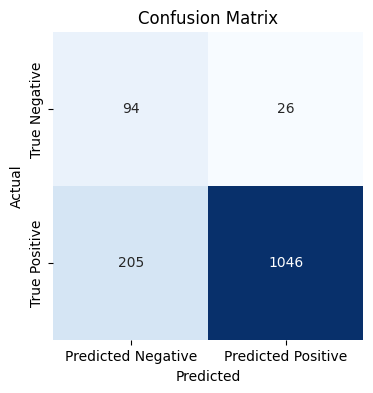

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.8315098468271335]
[np.float64(0.8097322142286171)]
[np.float64(0.8361310951239008)]
[np.float64(0.7833333333333333)]


### SVM

Accuracy:  0.8468271334792122
ROC-AUC:  0.784222621902478
Sensitivity:  0.8601119104716227
Specificity:  0.7083333333333334


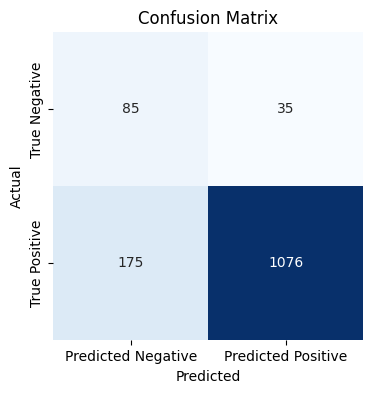

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.8468271334792122]
[np.float64(0.784222621902478)]
[np.float64(0.8601119104716227)]
[np.float64(0.7083333333333334)]


### XGBoost

Accuracy:  0.9117432530999271
ROC-AUC:  0.8649980015987211
Sensitivity:  0.9216626698641087
Specificity:  0.8083333333333333


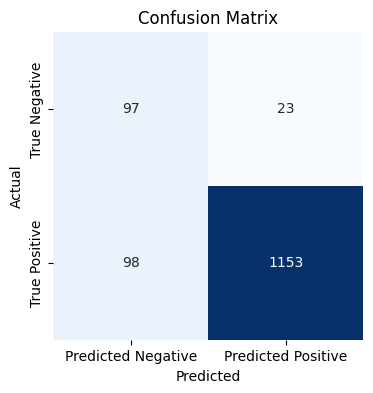

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.9117432530999271]
[np.float64(0.8649980015987211)]
[np.float64(0.9216626698641087)]
[np.float64(0.8083333333333333)]


### Triplet NN

In [ ]:
test_labels = np.asarray(external_test_labels)
train_labels = np.asarray(labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test, index0_test, index1_test = RS_splitter(external_test_set, test_labels)

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

120
3973
1251
3973


In [ ]:
x0_train, x1_train, index0_train, index1_train = RS_splitter(orig_data, orig_labels)

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1937
3973
4668
3973


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions
test_indices = []

for c, i in enumerate(x0_test):      #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])
  test_indices.append(index0_test[c]) # Index in original data

for c, i in enumerate(x1_test):
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])
  test_indices.append(index1_test[c]) # Index in original data
  # 10 min

#### TSA_Net evaluation

(Similarity test)

Accuracy:  0.9208526436022257
ROC-AUC:  0.8996063952617147
Sensitivity:  0.950152928666177
Specificity:  0.8490598618572525


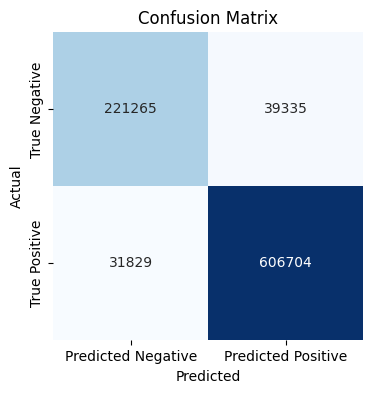

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9208526436022257]
[np.float64(0.8996063952617147)]
[np.float64(0.950152928666177)]
[np.float64(0.8490598618572525)]


#### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9102844638949672
ROC-AUC:  0.8302957633892887
Sensitivity:  0.9272581934452439
Specificity:  0.7333333333333333


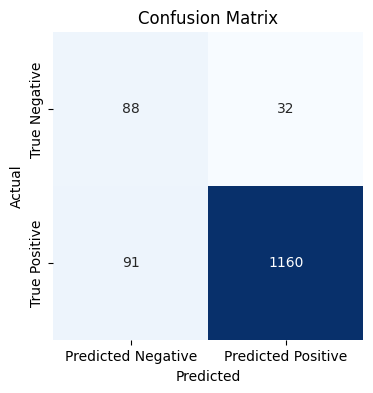

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

# Round 2

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(orig_data, orig_labels[:, 1])
predict_RF = model.predict(external_test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(orig_data, orig_labels[:, 1])
predict_SVM = model.predict(external_test_set)
# 20 s

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(orig_data, orig_labels[:, 1])
predict_XGB = model.predict(external_test_set)
# 11 s

#### Triplet NN

In [ ]:
# Making triplets
triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

19200
7065
19200
[1 0]


Preparing data

In [ ]:
triplet = np.asarray(triplet)
triplet.shape

(19200, 7065)

In [ ]:
pairedLabels = np.asarray(pairedLabels)
pairedLabels.shape

(19200, 2)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

Last Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9854 - auc-roc: 0.9980 - loss: 0.0427

## Validation

### RF

Accuracy:  0.8402625820568927
ROC-AUC:  0.7956934452438049
Sensitivity:  0.8497202238209433
Specificity:  0.7416666666666667


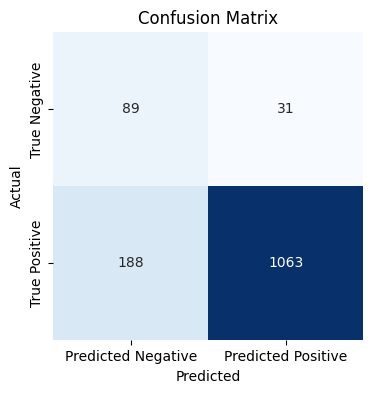

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.8315098468271335, 0.8402625820568927]
[np.float64(0.8097322142286171), np.float64(0.7956934452438049)]
[np.float64(0.8361310951239008), np.float64(0.8497202238209433)]
[np.float64(0.7833333333333333), np.float64(0.7416666666666667)]


### SVM

Accuracy:  0.8468271334792122
ROC-AUC:  0.784222621902478
Sensitivity:  0.8601119104716227
Specificity:  0.7083333333333334


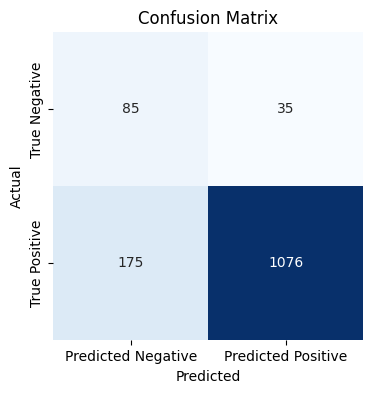

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.8468271334792122, 0.8468271334792122]
[np.float64(0.784222621902478), np.float64(0.784222621902478)]
[np.float64(0.8601119104716227), np.float64(0.8601119104716227)]
[np.float64(0.7083333333333334), np.float64(0.7083333333333334)]


### XGBoost

Accuracy:  0.9117432530999271
ROC-AUC:  0.8649980015987211
Sensitivity:  0.9216626698641087
Specificity:  0.8083333333333333


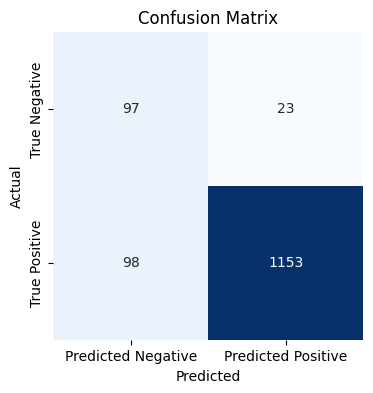

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.9117432530999271, 0.9117432530999271]
[np.float64(0.8649980015987211), np.float64(0.8649980015987211)]
[np.float64(0.9216626698641087), np.float64(0.9216626698641087)]
[np.float64(0.8083333333333333), np.float64(0.8083333333333333)]


### Triplet NN

In [ ]:
test_labels = np.asarray(external_test_labels)
train_labels = np.asarray(labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test, index0_test, index1_test = RS_splitter(external_test_set, test_labels)

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

120
3973
1251
3973


In [ ]:
x0_train, x1_train, index0_train, index1_train = RS_splitter(orig_data, orig_labels)

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1937
3973
4668
3973


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions
test_indices = []

for c, i in enumerate(x0_test):      #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])
  test_indices.append(index0_test[c]) # Index in original data


for c, i in enumerate(x1_test):
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])
  test_indices.append(index1_test[c]) # Index in original data

#### TSA_Net evaluation

(Similarity test)

Accuracy:  0.9210650704623231
ROC-AUC:  0.90254727241374
Sensitivity:  0.946602603154418
Specificity:  0.8584919416730622


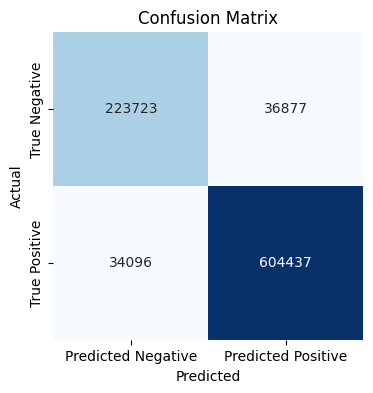

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9208526436022257, 0.9210650704623231]
[np.float64(0.8996063952617147), np.float64(0.90254727241374)]
[np.float64(0.950152928666177), np.float64(0.946602603154418)]
[np.float64(0.8490598618572525), np.float64(0.8584919416730622)]


#### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.8986141502552881
ROC-AUC:  0.8352018385291766
Sensitivity:  0.9120703437250199
Specificity:  0.7583333333333333


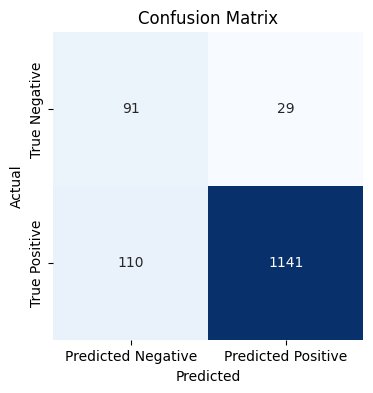

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9102844638949672, 0.8986141502552881]
[np.float64(0.8302957633892887), np.float64(0.8352018385291766)]
[np.float64(0.9272581934452439), np.float64(0.9120703437250199)]
[np.float64(0.7333333333333333), np.float64(0.7583333333333333)]


# Round 3

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(orig_data, orig_labels[:, 1])
predict_RF = model.predict(external_test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(orig_data, orig_labels[:, 1])
predict_SVM = model.predict(external_test_set)
# 20 s

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(orig_data, orig_labels[:, 1])
predict_XGB = model.predict(external_test_set)
# 11 s

#### Triplet NN

In [ ]:
# Making triplets
triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

19200
7065
19200
[1 0]


Preparing data

In [ ]:
triplet = np.asarray(triplet)
triplet.shape

(19200, 7065)

In [ ]:
pairedLabels = np.asarray(pairedLabels)
pairedLabels.shape

(19200, 2)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

Last Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9870 - auc-roc: 0.9985 - loss: 0.0392

## Validation

### RF

Accuracy:  0.8329686360320934
ROC-AUC:  0.8029976019184653
Sensitivity:  0.8393285371702638
Specificity:  0.7666666666666667


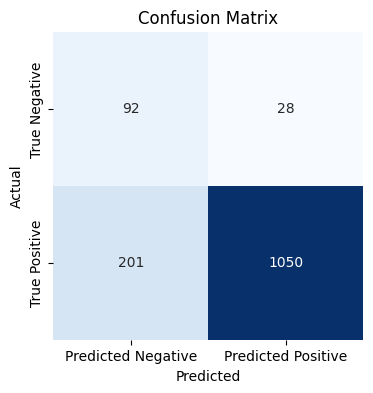

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.8315098468271335, 0.8402625820568927, 0.8329686360320934]
[np.float64(0.8097322142286171), np.float64(0.7956934452438049), np.float64(0.8029976019184653)]
[np.float64(0.8361310951239008), np.float64(0.8497202238209433), np.float64(0.8393285371702638)]
[np.float64(0.7833333333333333), np.float64(0.7416666666666667), np.float64(0.7666666666666667)]


### SVM

Accuracy:  0.8468271334792122
ROC-AUC:  0.784222621902478
Sensitivity:  0.8601119104716227
Specificity:  0.7083333333333334


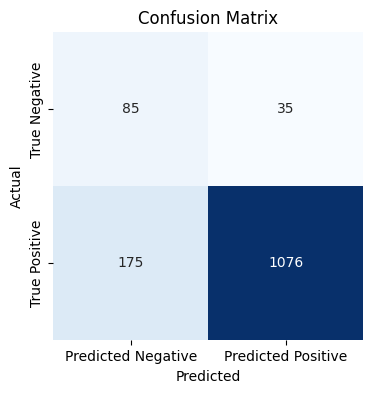

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.8468271334792122, 0.8468271334792122, 0.8468271334792122]
[np.float64(0.784222621902478), np.float64(0.784222621902478), np.float64(0.784222621902478)]
[np.float64(0.8601119104716227), np.float64(0.8601119104716227), np.float64(0.8601119104716227)]
[np.float64(0.7083333333333334), np.float64(0.7083333333333334), np.float64(0.7083333333333334)]


### XGBoost

Accuracy:  0.9117432530999271
ROC-AUC:  0.8649980015987211
Sensitivity:  0.9216626698641087
Specificity:  0.8083333333333333


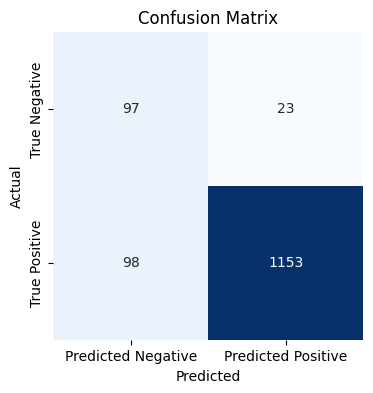

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.9117432530999271, 0.9117432530999271, 0.9117432530999271]
[np.float64(0.8649980015987211), np.float64(0.8649980015987211), np.float64(0.8649980015987211)]
[np.float64(0.9216626698641087), np.float64(0.9216626698641087), np.float64(0.9216626698641087)]
[np.float64(0.8083333333333333), np.float64(0.8083333333333333), np.float64(0.8083333333333333)]


### Triplet NN

In [ ]:
test_labels = np.asarray(external_test_labels)
train_labels = np.asarray(labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test, index0_test, index1_test = RS_splitter(external_test_set, test_labels)

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

120
3973
1251
3973


In [ ]:
x0_train, x1_train, index0_train, index1_train = RS_splitter(orig_data, orig_labels)

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1937
3973
4668
3973


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions
test_indices = []

for c, i in enumerate(x0_test):      #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])
  test_indices.append(index0_test[c]) # Index in original data


for c, i in enumerate(x1_test):
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])
  test_indices.append(index1_test[c]) # Index in original data

#### TSA_Net evaluation

(Similarity test)

Accuracy:  0.8786308588384588
ROC-AUC:  0.8450201466691989
Sensitivity:  0.9249827338602703
Specificity:  0.7650575594781274


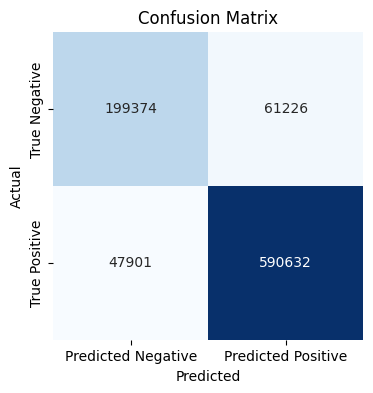

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9208526436022257, 0.9210650704623231, 0.8786308588384588]
[np.float64(0.8996063952617147), np.float64(0.90254727241374), np.float64(0.8450201466691989)]
[np.float64(0.950152928666177), np.float64(0.946602603154418), np.float64(0.9249827338602703)]
[np.float64(0.8490598618572525), np.float64(0.8584919416730622), np.float64(0.7650575594781274)]


#### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9015317286652079
ROC-AUC:  0.8330335731414868
Sensitivity:  0.9160671462829736
Specificity:  0.75


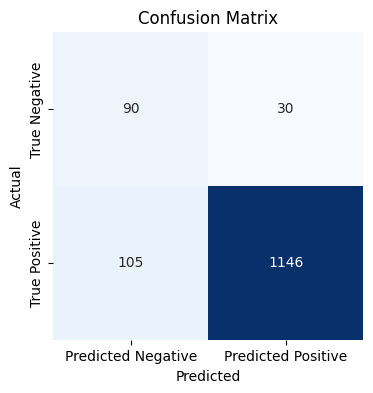

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9102844638949672, 0.8986141502552881, 0.9015317286652079]
[np.float64(0.8302957633892887), np.float64(0.8352018385291766), np.float64(0.8330335731414868)]
[np.float64(0.9272581934452439), np.float64(0.9120703437250199), np.float64(0.9160671462829736)]
[np.float64(0.7333333333333333), np.float64(0.7583333333333333), np.float64(0.75)]


# Round 4

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(orig_data, orig_labels[:, 1])
predict_RF = model.predict(external_test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(orig_data, orig_labels[:, 1])
predict_SVM = model.predict(external_test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(orig_data, orig_labels[:, 1])
predict_XGB = model.predict(external_test_set)

#### Triplet NN

In [ ]:
# Making triplets
triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

19200
7065
19200
[1 0]


Preparing data

In [ ]:
triplet = np.asarray(triplet)
triplet.shape

(19200, 7065)

In [ ]:
pairedLabels = np.asarray(pairedLabels)
pairedLabels.shape

(19200, 2)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

## Validation

### RF

Accuracy:  0.8409919766593728
ROC-AUC:  0.8036270983213429
Sensitivity:  0.8489208633093526
Specificity:  0.7583333333333333


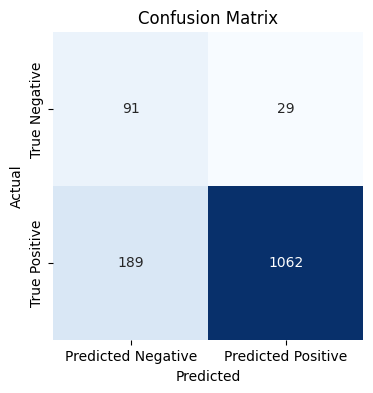

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.8315098468271335, 0.8402625820568927, 0.8329686360320934, 0.8409919766593728]
[np.float64(0.8097322142286171), np.float64(0.7956934452438049), np.float64(0.8029976019184653), np.float64(0.8036270983213429)]
[np.float64(0.8361310951239008), np.float64(0.8497202238209433), np.float64(0.8393285371702638), np.float64(0.8489208633093526)]
[np.float64(0.7833333333333333), np.float64(0.7416666666666667), np.float64(0.7666666666666667), np.float64(0.7583333333333333)]


### SVM

Accuracy:  0.8468271334792122
ROC-AUC:  0.784222621902478
Sensitivity:  0.8601119104716227
Specificity:  0.7083333333333334


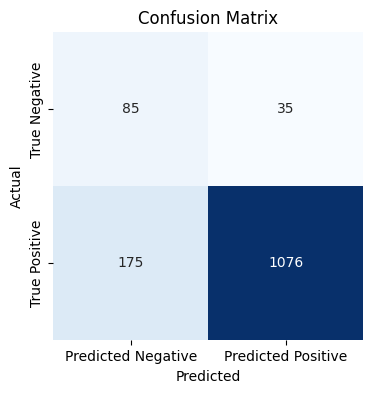

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.8468271334792122, 0.8468271334792122, 0.8468271334792122, 0.8468271334792122]
[np.float64(0.784222621902478), np.float64(0.784222621902478), np.float64(0.784222621902478), np.float64(0.784222621902478)]
[np.float64(0.8601119104716227), np.float64(0.8601119104716227), np.float64(0.8601119104716227), np.float64(0.8601119104716227)]
[np.float64(0.7083333333333334), np.float64(0.7083333333333334), np.float64(0.7083333333333334), np.float64(0.7083333333333334)]


### XGBoost

Accuracy:  0.9117432530999271
ROC-AUC:  0.8649980015987211
Sensitivity:  0.9216626698641087
Specificity:  0.8083333333333333


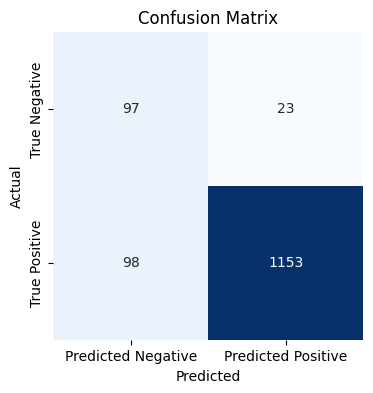

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.9117432530999271, 0.9117432530999271, 0.9117432530999271, 0.9117432530999271]
[np.float64(0.8649980015987211), np.float64(0.8649980015987211), np.float64(0.8649980015987211), np.float64(0.8649980015987211)]
[np.float64(0.9216626698641087), np.float64(0.9216626698641087), np.float64(0.9216626698641087), np.float64(0.9216626698641087)]
[np.float64(0.8083333333333333), np.float64(0.8083333333333333), np.float64(0.8083333333333333), np.float64(0.8083333333333333)]


### Triplet NN

In [ ]:
test_labels = np.asarray(external_test_labels)
train_labels = np.asarray(labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test, index0_test, index1_test = RS_splitter(external_test_set, test_labels)

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

120
3973
1251
3973


In [ ]:
x0_train, x1_train, index0_train, index1_train = RS_splitter(orig_data, orig_labels)

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1937
3973
4668
3973


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions
test_indices = []

for c, i in enumerate(x0_test):      #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])
  test_indices.append(index0_test[c]) # Index in original data


for c, i in enumerate(x1_test):
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])
  test_indices.append(index1_test[c]) # Index in original data

#### TSA_Net evaluation

(Similarity test)

Accuracy:  0.9222417595617111
ROC-AUC:  0.895838727598142
Sensitivity:  0.9586536639453247
Specificity:  0.8330237912509594


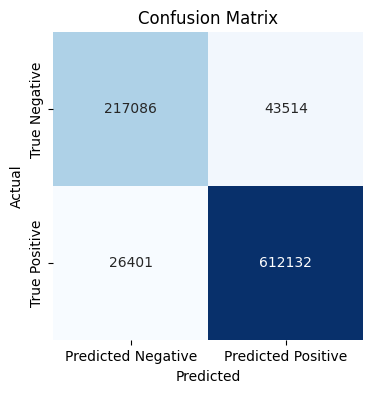

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9208526436022257, 0.9210650704623231, 0.8786308588384588, 0.9222417595617111]
[np.float64(0.8996063952617147), np.float64(0.90254727241374), np.float64(0.8450201466691989), np.float64(0.895838727598142)]
[np.float64(0.950152928666177), np.float64(0.946602603154418), np.float64(0.9249827338602703), np.float64(0.9586536639453247)]
[np.float64(0.8490598618572525), np.float64(0.8584919416730622), np.float64(0.7650575594781274), np.float64(0.8330237912509594)]


#### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.9270605397520059
ROC-AUC:  0.8055855315747403
Sensitivity:  0.9528377298161471
Specificity:  0.6583333333333333


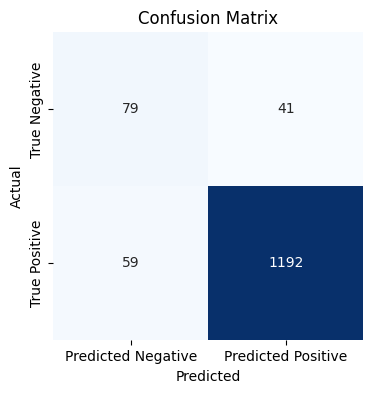

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9102844638949672, 0.8986141502552881, 0.9015317286652079, 0.9270605397520059]
[np.float64(0.8302957633892887), np.float64(0.8352018385291766), np.float64(0.8330335731414868), np.float64(0.8055855315747403)]
[np.float64(0.9272581934452439), np.float64(0.9120703437250199), np.float64(0.9160671462829736), np.float64(0.9528377298161471)]
[np.float64(0.7333333333333333), np.float64(0.7583333333333333), np.float64(0.75), np.float64(0.6583333333333333)]


# Round 5

### Training

#### Random Forest (RF)

In [ ]:
model = RandomForestClassifier(n_estimators=100).fit(orig_data, orig_labels[:, 1])
predict_RF = model.predict(external_test_set)

#### SVM

In [ ]:
model = SVC(kernel='poly').fit(orig_data, orig_labels[:, 1])
predict_SVM = model.predict(external_test_set)

#### XGBoost

In [ ]:
model = xgboost.XGBClassifier().fit(orig_data, orig_labels[:, 1])
predict_XGB = model.predict(external_test_set)

#### Triplet NN

In [ ]:
# Making triplets
triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

In [ ]:
print(len(triplet))
print(len(triplet[0]))
print(len(pairedLabels))
print(pairedLabels[0])

19200
7065
19200
[1 0]


Preparing data

In [ ]:
triplet = np.asarray(triplet)
triplet.shape

(19200, 7065)

In [ ]:
pairedLabels = np.asarray(pairedLabels)
pairedLabels.shape

(19200, 2)

In [ ]:
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

In [ ]:
num_epochs=10
history=History()
siamese_net = create_siamese_model(input_shape1, input_shape2, input_shape3)

print("Round: 1 ---> 1-10")
history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

for i in range(20-1):
  print("Round: ", i+2, '--->', (i+1)*10+1, '-', (i+2)*10)

  triplet, pairedLabels =  make_balanced_triplets(orig_data, orig_labels, drugs, 400)

  history = siamese_net.fit([[triplet[:, :bac_len],
                           triplet[:, bac_len:(bac_len+bac_len)]],
                           triplet[:, (bac_len+bac_len):]], pairedLabels[:, 0],
                          epochs=num_epochs, batch_size=64, verbose=1, callbacks=history)

## Validation

### RF

Accuracy:  0.8424507658643327
ROC-AUC:  0.8157274180655476
Sensitivity:  0.8481215027977618
Specificity:  0.7833333333333333


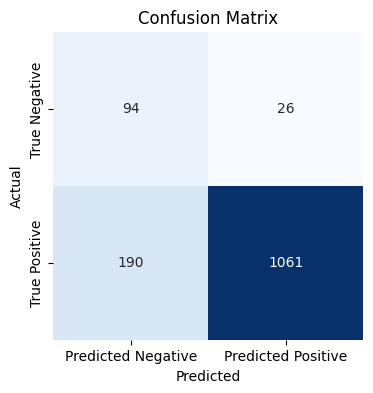

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_RF)

In [ ]:
rf_acc.append(acc)
rf_auc.append(auc)
rf_sen.append(sen)
rf_spc.append(spc)

In [ ]:
print(rf_acc)
print(rf_auc)
print(rf_sen)
print(rf_spc)

[0.8315098468271335, 0.8402625820568927, 0.8329686360320934, 0.8409919766593728, 0.8424507658643327]
[np.float64(0.8097322142286171), np.float64(0.7956934452438049), np.float64(0.8029976019184653), np.float64(0.8036270983213429), np.float64(0.8157274180655476)]
[np.float64(0.8361310951239008), np.float64(0.8497202238209433), np.float64(0.8393285371702638), np.float64(0.8489208633093526), np.float64(0.8481215027977618)]
[np.float64(0.7833333333333333), np.float64(0.7416666666666667), np.float64(0.7666666666666667), np.float64(0.7583333333333333), np.float64(0.7833333333333333)]


### SVM

Accuracy:  0.8468271334792122
ROC-AUC:  0.784222621902478
Sensitivity:  0.8601119104716227
Specificity:  0.7083333333333334


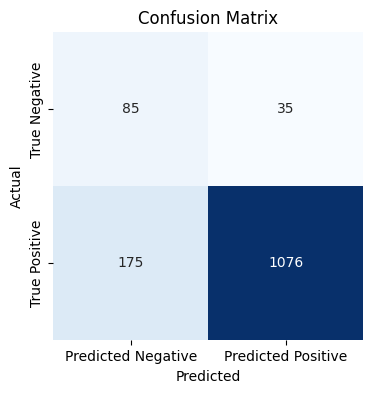

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_SVM)

In [ ]:
svm_acc.append(acc)
svm_auc.append(auc)
svm_sen.append(sen)
svm_spc.append(spc)

In [ ]:
print(svm_acc)
print(svm_auc)
print(svm_sen)
print(svm_spc)

[0.8468271334792122, 0.8468271334792122, 0.8468271334792122, 0.8468271334792122, 0.8468271334792122]
[np.float64(0.784222621902478), np.float64(0.784222621902478), np.float64(0.784222621902478), np.float64(0.784222621902478), np.float64(0.784222621902478)]
[np.float64(0.8601119104716227), np.float64(0.8601119104716227), np.float64(0.8601119104716227), np.float64(0.8601119104716227), np.float64(0.8601119104716227)]
[np.float64(0.7083333333333334), np.float64(0.7083333333333334), np.float64(0.7083333333333334), np.float64(0.7083333333333334), np.float64(0.7083333333333334)]


### XGBoost

Accuracy:  0.9117432530999271
ROC-AUC:  0.8649980015987211
Sensitivity:  0.9216626698641087
Specificity:  0.8083333333333333


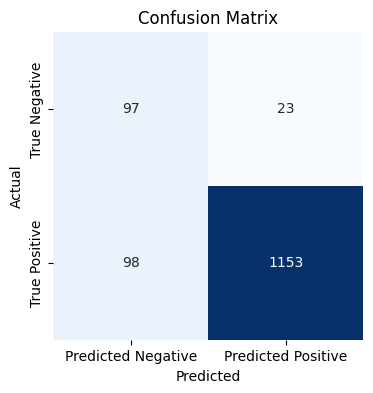

In [ ]:
acc, auc, sen, spc = evaluation(external_test_labels[:, 1], predict_XGB)

In [ ]:
xgb_acc.append(acc)
xgb_auc.append(auc)
xgb_sen.append(sen)
xgb_spc.append(spc)

In [ ]:
print(xgb_acc)
print(xgb_auc)
print(xgb_sen)
print(xgb_spc)

[0.9117432530999271, 0.9117432530999271, 0.9117432530999271, 0.9117432530999271, 0.9117432530999271]
[np.float64(0.8649980015987211), np.float64(0.8649980015987211), np.float64(0.8649980015987211), np.float64(0.8649980015987211), np.float64(0.8649980015987211)]
[np.float64(0.9216626698641087), np.float64(0.9216626698641087), np.float64(0.9216626698641087), np.float64(0.9216626698641087), np.float64(0.9216626698641087)]
[np.float64(0.8083333333333333), np.float64(0.8083333333333333), np.float64(0.8083333333333333), np.float64(0.8083333333333333), np.float64(0.8083333333333333)]


### Triplet NN

In [ ]:
test_labels = np.asarray(external_test_labels)
train_labels = np.asarray(labels)

In [ ]:
# splitting external_test_set to set of susceptible and resistant ones:
x0_test, x1_test, index0_test, index1_test = RS_splitter(external_test_set, test_labels)

In [ ]:
print(len(x0_test))
print(len(x0_test[0]))
print(len(x1_test))
print(len(x1_test[0]))

120
3973
1251
3973


In [ ]:
x0_train, x1_train, index0_train, index1_train = RS_splitter(orig_data, orig_labels)

In [ ]:
print(len(x0_train))
print(len(x0_train[0]))
print(len(x1_train))
print(len(x1_train[0]))

1937
3973
4668
3973


In [ ]:
x0_train = np.asarray(x0_train)
x1_train = np.asarray(x1_train)

In [ ]:
test_labels = []  # True labels for test samples.
aggre_preds = [] # Aggregated pred values for each sample, by DefineTest2 func.
internal_labels = [] # Labels form ExternalTest2 for internal test
internal_preds = [] # internal_labels corresponding predictions
test_indices = []

for c, i in enumerate(x0_test):      #x0_test, x1_test, x0_train, x1_train
  data, labels, indexSample = ExternalTest([i], [], x0_train, x1_train) # makes i couple with x0_train & x1_train
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([i], [], indexSample, predd)
  aggre_preds.append(y_pred[0][0]) # y_pred ---> [array([0.5], dtype=float32)]
  test_labels.append(label[0])
  test_indices.append(index0_test[c]) # Index in original data


for c, i in enumerate(x1_test):
  data, labels, indexSample = ExternalTest([], [i], x0_train, x1_train)
  internal_labels += labels.tolist()
  predd = siamese_net.predict([[data[:, :bac_len],
                           data[:, bac_len:(bac_len+bac_len)]],
                           data[:, (bac_len+bac_len):]], verbose=0)
  internal_preds += [i[0] for i in predd.tolist()]
  y_pred, label = DefineTest2([], [i], indexSample, predd)
  aggre_preds.append(y_pred[0][0])
  test_labels.append(label[0])
  test_indices.append(index1_test[c]) # Index in original data

#### TSA_Net evaluation

(Similarity test)

Accuracy:  0.876643388686657
ROC-AUC:  0.8539525741551349
Sensitivity:  0.9079358466986045
Specificity:  0.7999693016116654


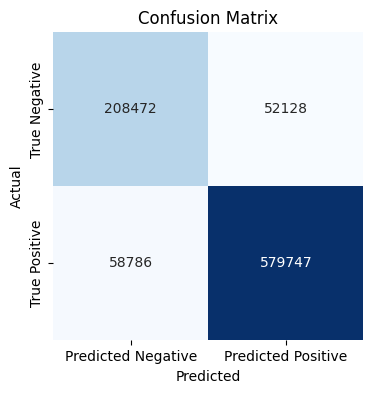

In [ ]:
acc, auc, sen, spc = evaluation(internal_labels, internal_preds)

In [ ]:
sim_acc.append(acc)
sim_auc.append(auc)
sim_sen.append(sen)
sim_spc.append(spc)

In [ ]:
print(sim_acc)
print(sim_auc)
print(sim_sen)
print(sim_spc)

[0.9208526436022257, 0.9210650704623231, 0.8786308588384588, 0.9222417595617111, 0.876643388686657]
[np.float64(0.8996063952617147), np.float64(0.90254727241374), np.float64(0.8450201466691989), np.float64(0.895838727598142), np.float64(0.8539525741551349)]
[np.float64(0.950152928666177), np.float64(0.946602603154418), np.float64(0.9249827338602703), np.float64(0.9586536639453247), np.float64(0.9079358466986045)]
[np.float64(0.8490598618572525), np.float64(0.8584919416730622), np.float64(0.7650575594781274), np.float64(0.8330237912509594), np.float64(0.7999693016116654)]


#### TripSimAcin_AMR evaluation

(Phenotype prediction test)

Accuracy:  0.8891320204230488
ROC-AUC:  0.8149380495603518
Sensitivity:  0.9048760991207034
Specificity:  0.725


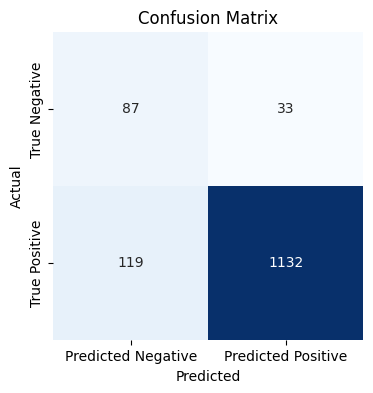

In [ ]:
acc, auc, sen, spc = evaluation(test_labels, aggre_preds)

In [ ]:
nn_acc.append(acc)
nn_auc.append(auc)
nn_sen.append(sen)
nn_spc.append(spc)

In [ ]:
print(nn_acc)
print(nn_auc)
print(nn_sen)
print(nn_spc)

[0.9102844638949672, 0.8986141502552881, 0.9015317286652079, 0.9270605397520059, 0.8891320204230488]
[np.float64(0.8302957633892887), np.float64(0.8352018385291766), np.float64(0.8330335731414868), np.float64(0.8055855315747403), np.float64(0.8149380495603518)]
[np.float64(0.9272581934452439), np.float64(0.9120703437250199), np.float64(0.9160671462829736), np.float64(0.9528377298161471), np.float64(0.9048760991207034)]
[np.float64(0.7333333333333333), np.float64(0.7583333333333333), np.float64(0.75), np.float64(0.6583333333333333), np.float64(0.725)]


# Results

## RF

In [ ]:
print("Average accuracy: ", sum(rf_acc)/len(rf_acc))
print("Average AUC: ", sum(rf_auc)/len(rf_auc))
print("Average sensitivity: ", sum(rf_sen)/len(rf_sen))
print("Average specificity: ", sum(rf_spc)/len(rf_spc))

Average accuracy:  0.837636761487965
Average AUC:  0.8055555555555556
Average sensitivity:  0.8444444444444444
Average specificity:  0.7666666666666666


## SVM

In [ ]:
print("Average accuracy: ", sum(svm_acc)/len(svm_acc))
print("Average AUC: ", sum(svm_auc)/len(svm_auc))
print("Average sensitivity: ", sum(svm_sen)/len(svm_sen))
print("Average specificity: ", sum(svm_spc)/len(svm_spc))

Average accuracy:  0.8468271334792122
Average AUC:  0.784222621902478
Average sensitivity:  0.8601119104716227
Average specificity:  0.7083333333333334


## XGB

In [ ]:
print("Average accuracy: ", sum(xgb_acc)/len(xgb_acc))
print("Average AUC: ", sum(xgb_auc)/len(xgb_auc))
print("Average sensitivity: ", sum(xgb_sen)/len(xgb_sen))
print("Average specificity: ", sum(xgb_spc)/len(xgb_spc))

Average accuracy:  0.911743253099927
Average AUC:  0.8649980015987211
Average sensitivity:  0.9216626698641088
Average specificity:  0.8083333333333333


## TripSimAcin_AMR

In [ ]:
print("Average accuracy: ", sum(nn_acc)/len(nn_acc))
print("Average AUC: ", sum(nn_auc)/len(nn_auc))
print("Average sensitivity: ", sum(nn_sen)/len(nn_sen))
print("Average specificity: ", sum(nn_spc)/len(nn_spc))

Average accuracy:  0.9053245805981035
Average AUC:  0.8238109512390089
Average sensitivity:  0.9226219024780177
Average specificity:  0.725


## TSA_Net

In [ ]:
print("Average accuracy: ", sum(sim_acc)/len(sim_acc))
print("Average AUC: ", sum(sim_auc)/len(sim_auc))
print("Average sensitivity: ", sum(sim_sen)/len(sim_sen))
print("Average specificity: ", sum(sim_spc)/len(sim_spc))

Average accuracy:  0.9038867442302753
Average AUC:  0.879393023219586
Average sensitivity:  0.937665555264959
Average specificity:  0.8211204911742133


In [ ]:
avg_acc = [sum(rf_acc)/len(rf_acc), sum(svm_acc)/len(svm_acc), sum(xgb_acc)/len(xgb_acc), sum(nn_acc)/len(nn_acc)]
print(avg_acc)

[0.837636761487965, 0.8468271334792122, 0.911743253099927, 0.9053245805981035]


In [ ]:
avg_auc = [sum(rf_auc)/len(rf_auc), sum(svm_auc)/len(svm_auc), sum(xgb_auc)/len(xgb_auc), sum(nn_auc)/len(nn_auc)]
print(avg_auc)

[np.float64(0.8055555555555556), np.float64(0.784222621902478), np.float64(0.8649980015987211), np.float64(0.8238109512390089)]


In [ ]:
avg_sen = [sum(rf_sen)/len(rf_sen), sum(svm_sen)/len(svm_sen), sum(xgb_sen)/len(xgb_sen), sum(nn_sen)/len(nn_sen)]
print(avg_sen)

[np.float64(0.8444444444444444), np.float64(0.8601119104716227), np.float64(0.9216626698641088), np.float64(0.9226219024780177)]


In [ ]:
avg_spc = [sum(rf_spc)/len(rf_spc), sum(svm_spc)/len(svm_spc), sum(xgb_spc)/len(xgb_spc), sum(nn_spc)/len(nn_spc)]
print(avg_spc)

[np.float64(0.7666666666666666), np.float64(0.7083333333333334), np.float64(0.8083333333333333), np.float64(0.725)]


In [ ]:
import pandas as pd

avg_acc = [sum(rf_acc)/len(rf_acc), sum(svm_acc)/len(svm_acc), sum(xgb_acc)/len(xgb_acc), sum(nn_acc)/len(nn_acc)]
std_acc = [np.std(rf_acc), np.std(svm_acc), np.std(xgb_acc), np.std(nn_acc)]

avg_auc = [sum(rf_auc)/len(rf_auc), sum(svm_auc)/len(svm_auc), sum(xgb_auc)/len(xgb_auc), sum(nn_auc)/len(nn_auc)]
std_auc = [np.std(rf_auc), np.std(svm_auc), np.std(xgb_auc), np.std(nn_auc)]

avg_sen = [sum(rf_sen)/len(rf_sen), sum(svm_sen)/len(svm_sen), sum(xgb_sen)/len(xgb_sen), sum(nn_sen)/len(nn_sen)]
std_sen = [np.std(rf_sen), np.std(svm_sen), np.std(xgb_sen), np.std(nn_sen)]

avg_spc = [sum(rf_spc)/len(rf_spc), sum(svm_spc)/len(svm_spc), sum(xgb_spc)/len(xgb_spc), sum(nn_spc)/len(nn_spc)]
std_spc = [np.std(rf_spc), np.std(svm_spc), np.std(xgb_spc), np.std(nn_spc)]

metrics = ['ACC', 'AUC', 'SEN', 'SPC']
models = ['RF', 'SVM', 'XGB', 'NN']

formatted_data = []
for i, metric_name in enumerate(metrics):
    row = []
    for j, model_name in enumerate(models):
        mean_val = globals()[f'avg_{metric_name.lower()}'][j]
        std_val = globals()[f'std_{metric_name.lower()}'][j]
        row.append(f'{mean_val:.3f} ({std_val:.3f})')
    formatted_data.append(row)

results_formatted = pd.DataFrame(formatted_data, columns=models, index=metrics)
display(results_formatted)

,RF,SVM,XGB,NN
ACC,0.838 (0.004),0.847 (0.000),0.912 (0.000),0.905 (0.013)
AUC,0.806 (0.007),0.784 (0.000),0.865 (0.000),0.824 (0.012)
SEN,0.844 (0.006),0.860 (0.000),0.922 (0.000),0.923 (0.017)
SPC,0.767 (0.016),0.708 (0.000),0.808 (0.000),0.725 (0.035)
